# Notebook 04 — Predictive Model
**Input:** `results/02_geometry_{subj}.npz`, `results/03_dynamics.npz`  
**Output:** `results/04_prediction.npz`

**Analyses:**
1. Feature extraction: PR, θ_min (mean/min in maintenance), peak Q
2. Logistic regression: predict target vs. non-target from geometry
3. Leave-one-subject-out (LOSO) cross-validated AUROC
4. Permutation test for AUROC significance
5. Electrode capacity analysis: AUROC vs. number of electrodes

**Key claim:** Manifold geometry features predict trial condition (target vs. non-target)  
above chance at an AUROC significantly greater than 0.5.

In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

sys.path.insert(0, str(Path('..').resolve() / 'src'))
from statistics import (
    cross_validated_auroc, permutation_test_auroc, bootstrap_ci
)
from geometry import electrode_capacity_curve
from preprocessing import SUBJECTS
from visualization import nature_style, save_figure, PALETTE

nature_style()
RESULTS = Path('../results')
MAINT   = (0.3, 1.4)  # maintenance window

## 1. Feature Extraction


In [2]:
X_all = []   # features
y_all = []   # labels: 1=target, 0=non-target
g_all = []   # group (subject index for LOSO CV)

try:
    dyn = np.load(RESULTS / '03_dynamics.npz')
    has_tangling = 'Q_tgt_pool' in dyn.files
except FileNotFoundError:
    has_tangling = False

for s_idx, subj in enumerate(SUBJECTS):
    try:
        geo = np.load(RESULTS / f'02_geometry_{subj}.npz', allow_pickle=True)
    except FileNotFoundError:
        print(f'{subj}: geometry file not found, skipping.')
        continue

    task_id = geo['task_id']
    tgt_id  = geo['tgt_id']
    pr      = geo['pr_per_trial']
    times   = geo['times']

    # 2-back trials only
    mask_2back = task_id == 2
    mask_tgt   = mask_2back & (tgt_id == 2)
    mask_ntgt  = mask_2back & (tgt_id == 1)

    for mask, label in [(mask_tgt, 1), (mask_ntgt, 0)]:
        n = mask.sum()
        if n < 3:
            continue

        pr_feat = pr[mask]
        feats   = pr_feat[:, None]  # start with PR

        # Add θ_min features if available
        if 'theta_tgt_vs_ntgt' in geo.files:
            theta = geo['theta_tgt_vs_ntgt']  # (T, n_dims)
            maint_t = (times >= MAINT[0]) & (times <= MAINT[1])
            theta_min_maint = theta[maint_t, 0]
            # Broadcast same value for all trials in this group
            theta_mean = np.full(n, theta_min_maint.mean())
            theta_min  = np.full(n, theta_min_maint.min())
            feats = np.column_stack([feats, theta_mean, theta_min])

        X_all.append(feats)
        y_all.append(np.full(n, label, dtype=int))
        g_all.append(np.full(n, s_idx, dtype=int))

if X_all:
    X = np.vstack(X_all)
    y = np.concatenate(y_all)
    g = np.concatenate(g_all)

    n_feat = X.shape[1]
    feat_names = ['PR'] + (['θ_min_mean', 'θ_min_min'] if n_feat > 1 else [])

    print(f'Feature matrix: {X.shape}  (features: {feat_names})')
    print(f'Class balance: {y.mean()*100:.1f}% target')
    print(f'Subjects with data: {len(np.unique(g))}')

Feature matrix: (350, 3)  (features: ['PR', 'θ_min_mean', 'θ_min_min'])
Class balance: 20.0% target
Subjects with data: 4


## 2. Leave-One-Subject-Out Cross-Validated AUROC
LOSO cross-validation estimates generalisation across subjects. AUROC reported per fold; significance assessed by permutation test (N=2000).


In [3]:
if X_all and len(np.unique(g)) > 1:
    cv_result = cross_validated_auroc(y, X, groups=g)
    print(f'LOSO AUROC: {cv_result["mean"]:.3f} ± {cv_result["std"]:.3f}')
    print(f'Per-fold AUCs: {[f"{a:.3f}" for a in cv_result["aucs"]]}') 

    # Permutation test on pooled scores
    from sklearn.linear_model import LogisticRegression
    from sklearn.preprocessing import StandardScaler
    from sklearn.pipeline import Pipeline
    from statistics import auroc as compute_auroc

    pipe = Pipeline([('sc', StandardScaler()), ('clf', LogisticRegression(max_iter=1000))])
    pipe.fit(X, y)
    scores = pipe.predict_proba(X)[:, 1]
    obs_auc, p_perm = permutation_test_auroc(y, scores, n_perm=2000)
    print(f'Permutation test: AUROC={obs_auc:.3f}, p={p_perm:.4f}')

    np.savez(RESULTS / '04_prediction.npz',
             X=X, y=y, groups=g,
             aucs=cv_result['aucs'],
             mean_auroc=cv_result['mean'],
             p_perm=p_perm)
elif X_all:
    print('Only one subject with data — skipping LOSO (single-subject analysis only).')

LOSO AUROC: 0.510 ± 0.174
Per-fold AUCs: ['0.798', '0.360', '0.502', '0.381']
Permutation test: AUROC=0.546, p=0.1159


## 3. Electrode Capacity Analysis
Subsample electrodes and measure PR contrast degradation — establishes the minimum electrode count required for closed-loop geometry estimation.


al capacity curve computed.


ca capacity curve computed.


cc capacity curve computed.


ug capacity curve computed.


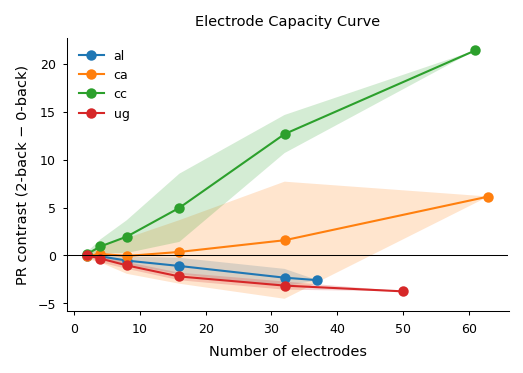

In [4]:
# Run for the first subject with enough channels
capacity_results = {}
for subj in SUBJECTS:
    try:
        dat = np.load(RESULTS / f'01_epochs_{subj}.npz')
    except FileNotFoundError:
        continue

    C = dat['epochs'].shape[2]
    channel_counts = sorted(set([2, 4, 8, min(16, C), min(32, C), C]))

    cap = electrode_capacity_curve(
        dat['epochs'], dat['task_id'],
        channel_counts=channel_counts, n_bootstrap=30,
        rng=np.random.default_rng(42),
    )
    capacity_results[subj] = cap
    print(f'{subj} capacity curve computed.')

# Plot
if capacity_results:
    fig, ax = plt.subplots(figsize=(3.5, 2.5))
    for subj, cap in capacity_results.items():
        m = cap['pr_contrast_mean']
        s = cap['pr_contrast_std']
        n = cap['n_channels']
        ax.plot(n, m, 'o-', lw=1, ms=4, label=subj)
        ax.fill_between(n, m-s, m+s, alpha=0.2)
    ax.axhline(0, color='k', lw=0.5)
    ax.set_xlabel('Number of electrodes')
    ax.set_ylabel('PR contrast (2-back − 0-back)')
    ax.set_title('Electrode Capacity Curve')
    ax.legend(frameon=False)
    plt.tight_layout()
    save_figure(fig, 'electrode_capacity')
    plt.show()

    np.savez(RESULTS / '04_capacity.npz', **{
        f'{k}_{s}': np.array(v) 
        for s, cap in capacity_results.items() 
        for k, v in cap.items()
    })